# Primeiros passos

Bibliotecas

In [124]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, plotting, image
from nilearn import plotting
import matplotlib.pyplot as plt
import cv2

Baixando automaticamente um MRI estrutural (T1) de referência

In [125]:
dataset = datasets.fetch_icbm152_2009()


[fetch_icbm152_2009] Dataset found in C:\Users\marip\nilearn_data\icbm152_2009


Carrega a imagem T1

In [126]:
img = nib.load(dataset.t1)

Inspecionando o básico

In [127]:
print("Shape:", img.shape)
print("Voxel size:", img.header.get_zooms())
print("Tipo dos dados:", img.get_fdata().dtype)

Shape: (197, 233, 189)
Voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Tipo dos dados: float64


Visualização

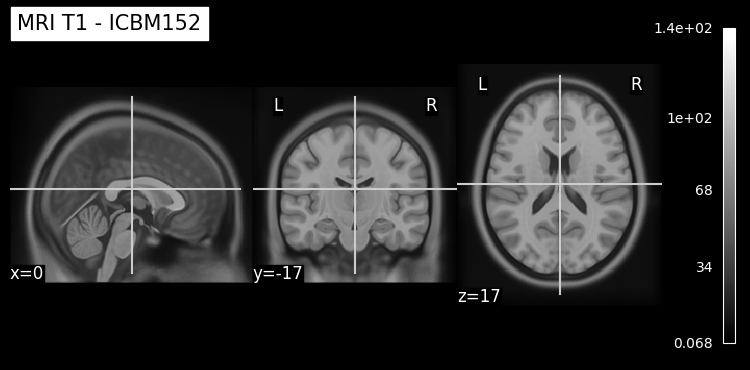

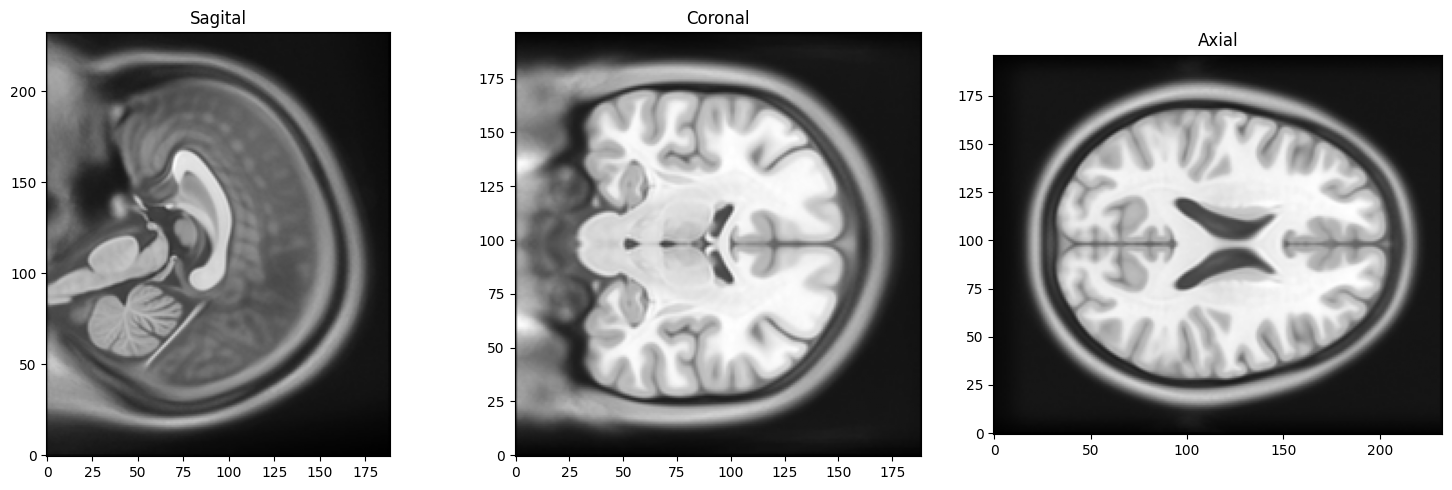

In [128]:
plotting.plot_anat(dataset.t1, title="MRI T1 - ICBM152")
plotting.show()

#Ver as três orientações manualmente
data = img.get_fdata()
meio = [s // 2 for s in data.shape]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(data[meio[0], :, :], cmap="gray", origin="lower")
axes[0].set_title("Sagital")
axes[1].imshow(data[:, meio[1], :], cmap="gray", origin="lower")
axes[1].set_title("Coronal")
axes[2].imshow(data[:, :, meio[2]], cmap="gray", origin="lower")
axes[2].set_title("Axial")
plt.tight_layout()
plt.show()

Disponível no dataset ICBM152

In [129]:
print(dataset.keys())

dict_keys(['description', 'csf', 'gm', 'wm', 'pd', 't1', 't2', 't2_relax', 'eye_mask', 'face_mask', 'mask'])


Comparação de imagens T1 e T2

C:\Users\marip\AppData\Local\Temp\ipykernel_24072\1416074199.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


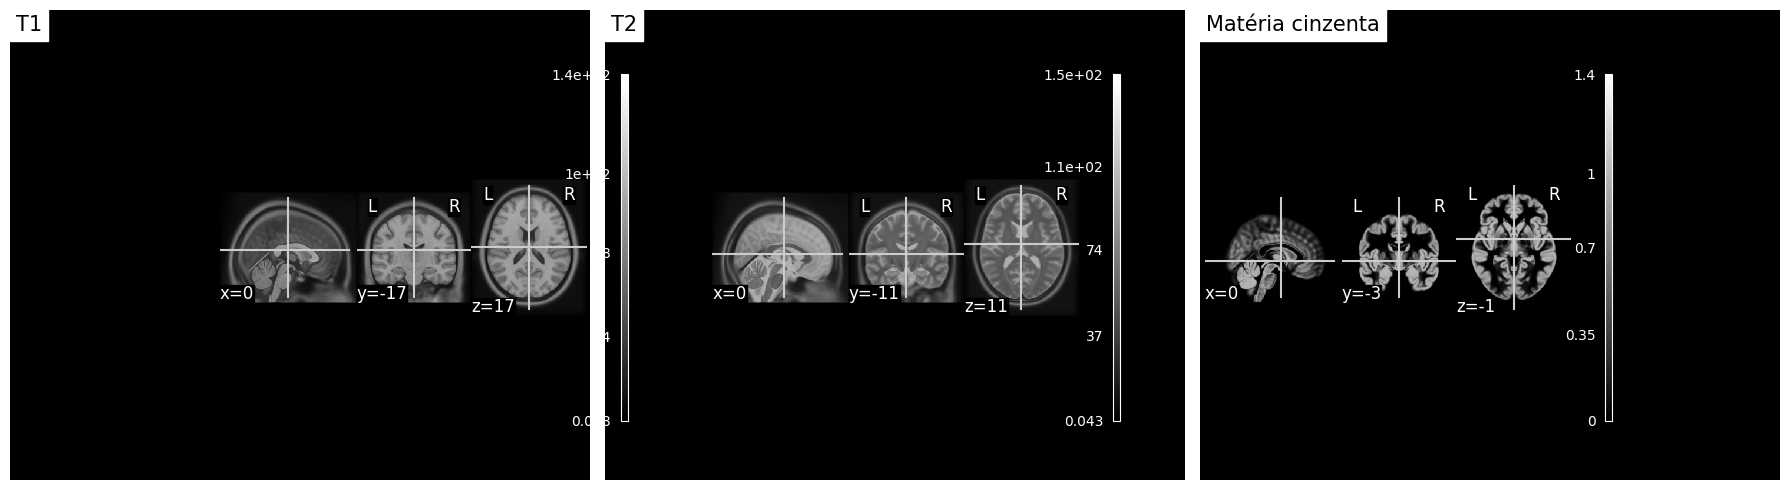

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plotting.plot_anat(dataset.t1, title="T1", axes=axes[0])
plotting.plot_anat(dataset.t2, title="T2", axes=axes[1])
plotting.plot_anat(dataset.gm, title="Matéria cinzenta", axes=axes[2])

plt.tight_layout()
plt.show()

# Visualizar corte axial

Slice central

In [131]:
#Tranformar o dataset em array primeiro
data = img.get_fdata()

In [132]:


slice_idx = data.shape[2] // 2

slice_axial = data[:, :, slice_idx]

Mostrar imagem

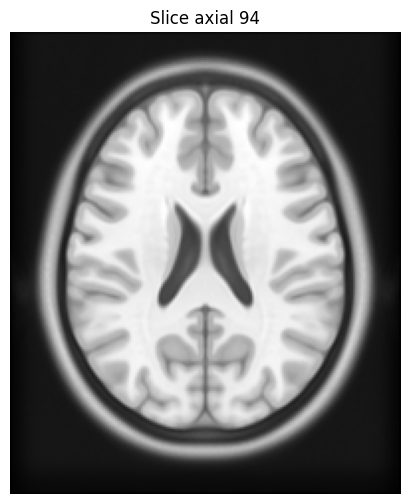

In [133]:
plt.figure(figsize=(6,6))
plt.imshow(slice_axial.T, cmap="gray", origin="lower")
plt.title(f"Slice axial {slice_idx}")
plt.axis("off")
plt.show()

Em T1: 
* líquor → escuro
* substância branca → clara

Em T2: 
* líquor → brilhante

## Navegação pelos slices

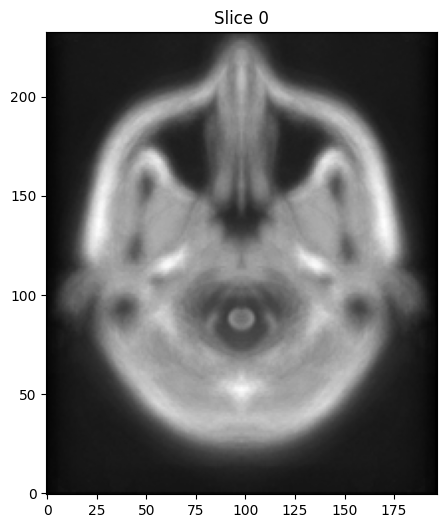

In [134]:
fig, ax = plt.subplots(figsize=(6,6))

for i in range(0, data.shape[2], 10):

    ax.clear()

    ax.imshow(data[:, :, i].T,
              cmap="gray",
              origin="lower")

    ax.set_title(f"Slice {i}")

    plt.pause(0.3)

plt.close()

Exportar imagens
* imagens 2D
* prontas para CV
* prontas para anotação

In [135]:
import os

output_dir = "../outputs/slices_axiais"

for i in range(data.shape[2]):

    plt.imsave(
        f"{output_dir}/slice_{i:03d}.png",
        data[:, :, i].T,
        cmap="gray"
    )

## Threshold simples

Normalização

In [136]:
slice_img = data[:, :, slice_idx]

slice_norm = (
    slice_img - slice_img.min()
) / (
    slice_img.max() - slice_img.min()
)

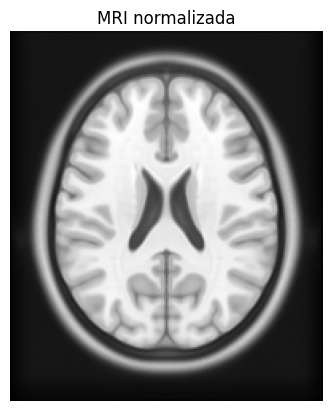

In [137]:
plt.imshow(
    slice_norm.T,
    cmap="gray",
    origin="lower"
)

plt.title("MRI normalizada")
plt.axis("off")
plt.show()

In [138]:
binary = slice_norm > 0.1

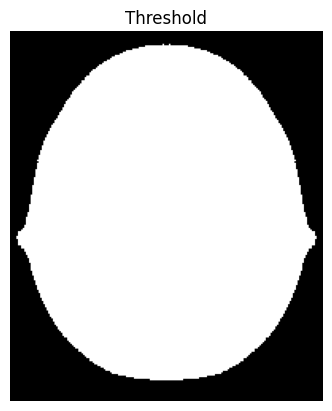

In [139]:
plt.imshow(
    binary.T,
    cmap="gray",
    origin="lower"
)

plt.title("Threshold")
plt.axis("off")
plt.show()

## Criando o contorno

In [140]:
binary_uint8 = (binary * 255).astype(np.uint8)

In [141]:
contours, _ = cv2.findContours(
    binary_uint8,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

Pegar o maior contorno, correspondende ao raio do crânio

In [142]:
largest_contour = max(
    contours,
    key=cv2.contourArea
)

In [143]:
canvas = np.zeros_like(binary_uint8)
canvas = np.ascontiguousarray(canvas)



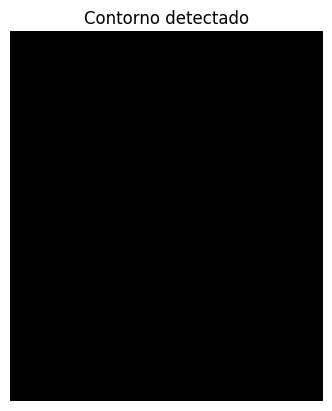

In [144]:
plt.imshow(
    canvas.T,
    cmap="gray",
    origin="lower"
)

plt.title("Contorno detectado")
plt.axis("off")
plt.show()

## Largura craniana

Bounding Box

In [145]:
x, y, w, h = cv2.boundingRect(largest_contour)

print(x, y, w, h)

13 4 212 189


em que: 

* (x, y) = canto superior esquerdo
* w = largura
* h = altura

In [146]:
canvas_box = cv2.cvtColor(
    canvas,
    cv2.COLOR_GRAY2BGR
)

cv2.rectangle(
    canvas_box,
    (x, y),
    (x + w, y + h),
    (255, 255, 255),
    2
)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(197, 233, 3), dtype=uint8)

Converter para medida física (spacing)

In [147]:
spacing = img.header.get_zooms()

print(spacing)

(np.float32(1.0), np.float32(1.0), np.float32(1.0))


largura anatômica real aproximada:

In [148]:
width_skull_mm = w * spacing[0]

print(width_skull_mm)

212.0


## Identificar ventrículos

In [149]:
img_t2 = nib.load(dataset.t2)

In [150]:
#Tranformar o dataset em array
data_t2 = img_t2.get_fdata()

Normalização

In [151]:
# slice axial
slice_img_t2 = data_t2[:, :, slice_idx]

# percentis para reduzir outliers
p2 = np.percentile(slice_img_t2, 2)
p98 = np.percentile(slice_img_t2, 98)

# clipping
slice_clip = np.clip(slice_img_t2, p2, p98)

# normalização 0-1
slice_norm_t2 = (
    slice_clip - slice_clip.min()
) / (
    slice_clip.max() - slice_clip.min()
)

In [152]:
ventricles = slice_norm_t2 > 0.8

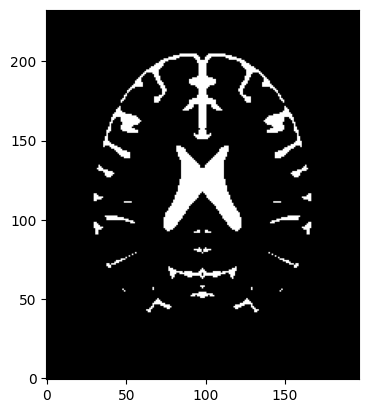

In [153]:
plt.imshow(
    ventricles.T,
    cmap="gray",
    origin="lower"
)

## Remover ruídos

In [154]:
ventricles_uint8 = (
    ventricles * 255
).astype(np.uint8)

kernel = np.ones((3,3), np.uint8)

clean = cv2.morphologyEx(
    ventricles_uint8,
    cv2.MORPH_OPEN,
    kernel
)

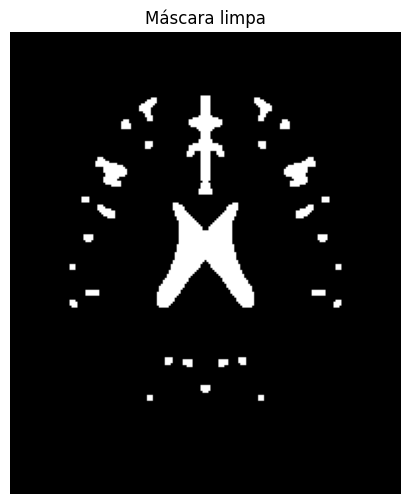

In [155]:
plt.figure(figsize=(6,6))

plt.imshow(
    clean.T,
    cmap="gray",
    origin="lower"
)

plt.title("Máscara limpa")
plt.axis("off")

plt.show()

Mapeando regiões semelhantes

In [156]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(clean)

#Quantas regiões
print(num_labels)

30


Explorar estatísticas
coluna 0: x
coluna 1: y
coluna 2: largura
coluna 3: altura
coluna 4: área

In [157]:
print(stats)

[[    0     0   233   197 43516]
 [   94    30     4     4    14]
 [  113    30     3     3     9]
 [  127    37     4     5    18]
 [  147    36     3     4    12]
 [  100    38     3     7    21]
 [  155    43    15    16   132]
 [  139    44     7     9    39]
 [  184    56     5     5    22]
 [  188    65    12     9    57]
 [   47    69     3     3     9]
 [  174    68     4     4    15]
 [   94    74    53    49  1219]
 [   65    78     4     4    15]
 [   64    87     4     5    18]
 [  151    89    50    19   386]
 [   51    96     4     5    18]
 [   64   105     4     5    18]
 [   65   115     4     4    15]
 [  188   123    12     9    57]
 [   47   125     3     3     9]
 [  174   125     4     4    15]
 [  184   136     5     5    22]
 [  155   138    15    16   132]
 [  139   144     7     9    39]
 [  100   152     3     7    21]
 [  127   155     4     5    18]
 [  147   157     3     4    12]
 [   94   163     4     4    14]
 [  113   164     3     3     9]]


Colorir regiões

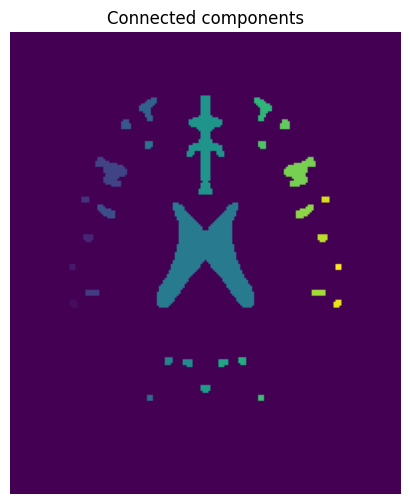

In [158]:
plt.figure(figsize=(6,6))

plt.imshow(labels.T, origin="lower")

plt.title("Connected components")
plt.axis("off")

plt.show()

Removendo ruído pelas áreas menores

In [159]:
min_area = 100

filtered_mask = np.zeros_like(clean)

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area > min_area:

        filtered_mask[labels == i] = 255

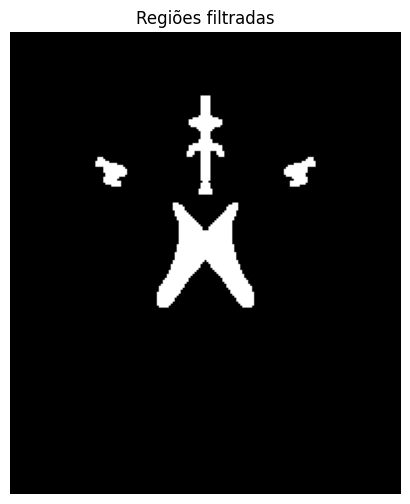

In [160]:
plt.figure(figsize=(6,6))

plt.imshow(
    filtered_mask.T,
    cmap="gray",
    origin="lower"
)

plt.title("Regiões filtradas")
plt.axis("off")

plt.show()

## Isolar ventrículos

Encontrar centro da imagem

In [161]:
h, w = clean.shape

center_x = w // 2
center_y = h // 2

In [162]:
for i in range(1, num_labels):

    cx, cy = centroids[i]

    distance = np.sqrt(
        (cx - center_x)**2 +
        (cy - center_y)**2
    )

    print(i, distance)

1 69.58807369082723
2 67.02984409947557
3 60.34438204542693
4 68.44158092855541
5 58.9406481131655
6 65.93444174599713
7 56.18231920678419
8 80.47058135001834
9 83.1946028980826
10 73.53910524340094
11 66.10688315145404
12 2.965545529122238
13 52.785604098087205
14 51.10256571075685
15 60.670984455958546
16 63.333333333333336
17 51.10256571075685
18 52.785604098087205
19 83.1946028980826
20 73.53910524340094
21 66.10688315145404
22 80.47058135001834
23 65.93444174599713
24 56.18231920678417
25 58.9406481131655
26 60.34438204542693
27 68.44158092855541
28 69.58807369082723
29 67.02984409947557


Desenhar centroides

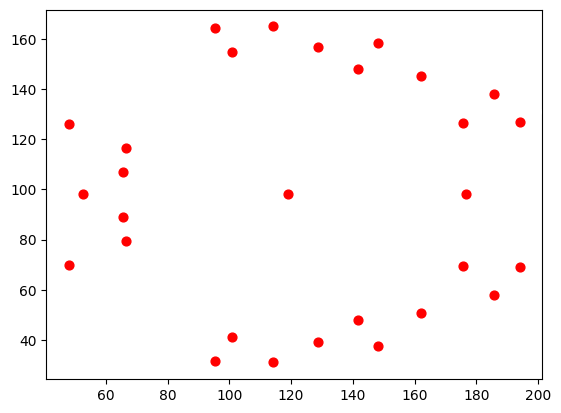

In [163]:
for i in range(1, num_labels):

    cx, cy = centroids[i]

    plt.scatter(
        cx,
        cy,
        c="red",
        s=40
    )

    plt.text(
        cx + 2,
        cy + 2,
        str(i),
        color="white",
        fontsize=10
    )

In [164]:
print(labels.min(), labels.max())

0 29


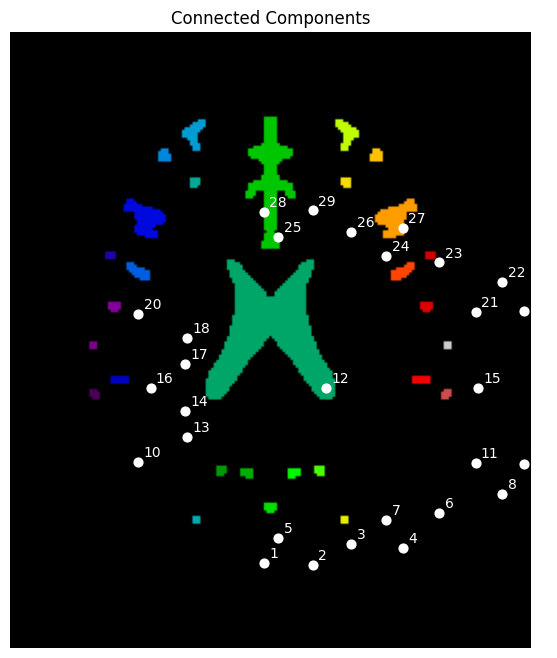

In [165]:
plt.figure(figsize=(8,8))

plt.imshow(
    labels.T,
    cmap="nipy_spectral",
    origin="lower"
)

for i in range(1, num_labels):

    cx, cy = centroids[i]

    plt.scatter(
        cx,
        cy,
        c="white",
        s=40
    )

    plt.text(
        cx + 2,
        cy + 2,
        str(i),
        color="white",
        fontsize=10
    )

plt.title("Connected Components")
plt.axis("off")

plt.show()

Selecionando a estrutura correspondente ao ponto 12

Investigar ponto 12

In [166]:
target = 12

candidate = np.zeros_like(clean)

candidate[labels == target] = 255

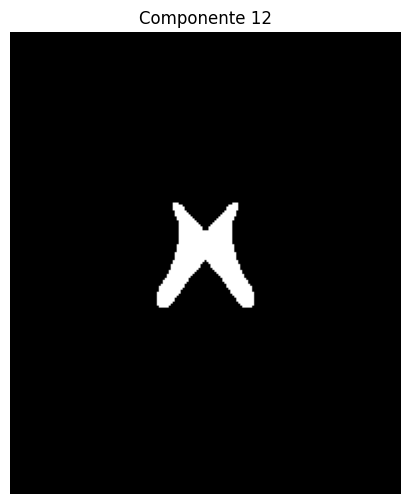

In [167]:
plt.figure(figsize=(6,6))

plt.imshow(
    candidate.T,
    cmap="gray",
    origin="lower"
)

plt.title("Componente 12")
plt.axis("off")

plt.show()

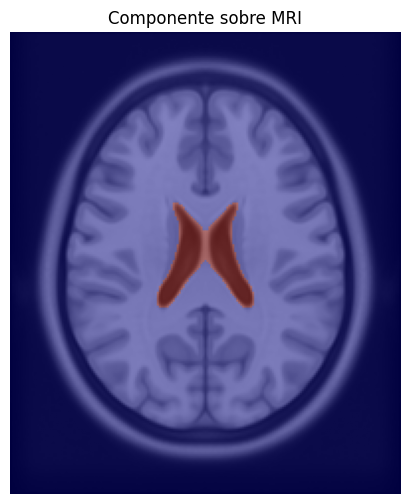

In [168]:
plt.figure(figsize=(6,6))

plt.imshow(
    slice_norm.T,
    cmap="gray",
    origin="lower"
)

plt.imshow(
    candidate.T,
    cmap="jet",
    alpha=0.5,
    origin="lower"
)

plt.title("Componente sobre MRI")
plt.axis("off")

plt.show()

Calcular largura e altura

In [169]:
target = 12

x = stats[target, cv2.CC_STAT_LEFT]
y = stats[target, cv2.CC_STAT_TOP]

w = stats[target, cv2.CC_STAT_WIDTH]
h = stats[target, cv2.CC_STAT_HEIGHT]

print(f"Largura: {w}")
print(f"Altura: {h}")

Largura: 53
Altura: 49


Converter para mm

In [170]:
spacing = img.header.get_zooms()

width_vent_mm = w * spacing[0]
height_vent_mm = h * spacing[1]

print(f"Largura ventricular: {width_vent_mm:.2f} mm")
print(f"Altura ventricular: {height_vent_mm:.2f} mm")

Largura ventricular: 53.00 mm
Altura ventricular: 49.00 mm


## Índice de Evans

In [171]:
evans_index = width_vent_mm / width_skull_mm

print(f"Evans Index: {evans_index:.3f}")

Evans Index: 0.250
